### Model Integration with GOOGLE GEMINI and GROQ

In [16]:
import os
from dotenv import load_dotenv
load_dotenv()

True

## INTEGRATION WITH GROQ 

In [17]:
# 1st way
from langchain.chat_models import init_chat_model

os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")
model = init_chat_model("groq:qwen/qwen3.8-27b")
response = model.invoke("What is the use of Langchain?")
response

AIMessage(content='**LangChain** is an open-source framework designed to simplify the development of applications powered by Large Language Models (LLMs). Its primary goal is to provide the tools and abstractions needed to build LLM-powered applications that go beyond simple chatbots.\n\nHere are the key uses and benefits of LangChain:\n\n### 1. **Building LLM Applications**\n   - Enables developers to create sophisticated applications such as chatbots, question-answering systems, summarization tools, and autonomous agents.\n   - Provides a standardized interface to work with different LLMs (e.g., OpenAI, Anthropic, Hugging Face, local models like Llama).\n\n### 2. **Chains**\n   - **Definition**: A sequence of steps that an LLM follows to accomplish a task.\n   - **Use Case**: For example, a chain might first summarize a document, then generate questions based on the summary, and finally answer those questions.\n   - LangChain provides pre-built chains and allows you to create custom 

In [19]:
# 2nd way 
from langchain_groq import ChatGroq

model = ChatGroq(model = "qwen/qwen3.8-27b")
response = model.invoke("What is RAG?")
response

AIMessage(content='**RAG** stands for **Retrieval-Augmented Generation**. It is a hybrid approach in artificial intelligence that combines the capabilities of large language models (LLMs) with an external knowledge base to improve the accuracy and relevance of generated responses.\n\n### How RAG Works (Step-by-Step)\n\n1.  **Retrieval**:\n    *   When a user asks a question, the system first **retrieves** relevant information from a predefined, external data source (e.g., a company’s internal documents, a knowledge base, or a database).\n    *   This is typically done using vector similarity search (e.g., using embeddings) to find the most semantically similar chunks of text to the user’s query.\n\n2.  **Augmentation**:\n    *   The retrieved information is **augmented** (added) to the user’s original prompt.\n    *   The prompt now includes both the user’s question and the context from the external data source.\n\n3.  **Generation**:\n    *   The LLM generates a response based on the 

## Integration with Google Gemini

In [ ]:
from langchain.chat_models import init_chat_model

os.environ["GOOGLE_API_KEY"] = os.getenv("GOOGLE_API_KEY")
model = init_chat_model("google_genai:gemini-3.5-flash-lite")
response = model.invoke("What is Agentic AI?")
response

In [ ]:
from langchain_google_genai import ChatGoogleGenerativeAI

model = ChatGoogleGenerativeAI(model="gemini-3.5-flash-lite")
response = model.invoke("What is the use of Langchain?")
response

### Streaming and Batch

## Streaming

Most models can stream their output content while it is being generated. By displaying output progressively, streaming significantly improves user experience, particularly for longer responses.Calling stream() returns an iterator that yields output chunks as they are produced. You can use a loop to process each chunk in real-time.

In [26]:
for chunk in model.stream("What is the benefit of Langchain?"):
    print(chunk.text, end="", flush=True)

LangChain is a popular open-source framework designed to facilitate the development of applications powered by Large Language Models (LLMs). Its primary benefits stem from its ability to **modularize**, **orchestrate**, and **simplify** the complex workflows required to build production-ready AI applications.

Here are the key benefits of using LangChain:

### 1. **Abstraction and Standardization**
- **Unified APIs**: LangChain provides consistent interfaces for different LLM providers (OpenAI, Anthropic, Hugging Face, etc.), vector stores (Pinecone, FAISS, Chroma, etc.), and document loaders. This reduces code duplication and makes it easier to switch underlying components without rewriting your entire application.
- **Modular Components**: It breaks down complex AI applications into reusable, composable units (Prompts, Models, Retriever, Chains, Agents), making code more maintainable and testable.

### 2. **Simplified Integration with External Tools and Data**
- **Tool Use**: LangCha

## Batch

Batching a collection of independent requests to a model can significantly improve the performance and reduce costs as processing can be done in parallel. 

In [27]:
responses = model.batch([
    "What are the use of Langchain?",
    "What are the uses of RAG?",
    "How are Langchain and Rag connected?",
    ],
    config={
        'max_concurrency':5,  # Limit to 5 parallel cells
    }
    )
for response in responses:
    print(response)

content='LangChain is a framework designed to make it easier to develop applications powered by Large Language Models (LLMs). Its primary purpose is to abstract away the complexity of working with LLMs, allowing developers to build robust, production-ready AI applications more efficiently.\n\nHere are the main uses and capabilities of LangChain:\n\n### 1. **Chain LLM Calls Together**\nLangChain allows you to create "chains" where the output of one LLM call becomes the input for the next. This is useful for:\n- Multi-step reasoning tasks.\n- Breaking down complex prompts into smaller, manageable parts.\n- Combining multiple models for different tasks (e.g., one model for summarization, another for translation).\n\n### 2. **Retrieval-Augmented Generation (RAG)**\nThis is one of LangChain’s most popular use cases. It enables LLMs to access external, up-to-date, or private data sources.\n- **Vector Stores**: Connect to databases like Pinecone, Weaviate, Chroma, or FAISS to store and retrie

In [37]:
from langchain.tools import tool

@tool
def get_weather(location:str)->str:
    """Get the weather at a location"""
    return f"Its sunny in {location}."

model_with_tools = model.bind_tools([get_weather])

In [38]:
response = model_with_tools.invoke("What is the weather like in Boston?")
print(response)
for tool_call in response.tool_calls:
    # View tool calls made by the model
    print(f"Tool:{tool_call['name']}")
    print(f"Args:{tool_call['args']}")

content='' additional_kwargs={'tool_calls': [{'id': 'zjkdtxr1t', 'function': {'arguments': '{"location":"Boston"}', 'name': 'get_weather'}, 'type': 'function'}]} response_metadata={'token_usage': {'completion_tokens': 26, 'prompt_tokens': 278, 'total_tokens': 304, 'completion_time': 0.068544093, 'completion_tokens_details': None, 'prompt_time': 0.02030929, 'prompt_tokens_details': None, 'queue_time': 0.100917817, 'total_time': 0.088853383}, 'model_name': 'qwen/qwen3.8-27b', 'system_fingerprint': 'fp_a1293f40b5', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'} id='lc_run--01a0e8a7-3b57-7e53-bd4e-1f086abecbce-0' tool_calls=[{'name': 'get_weather', 'args': {'location': 'Boston'}, 'id': 'zjkdtxr1t', 'type': 'tool_call'}] invalid_tool_calls=[] usage_metadata={'input_tokens': 278, 'output_tokens': 26, 'total_tokens': 304}
Tool:get_weather
Args:{'location': 'Boston'}


## ⭐ Tool Execution Loop

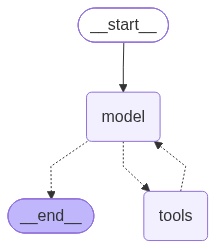

In [35]:
from langchain.agents import create_agent

def get_weather(city:str)->str:
    """ Get the weather for a city. """
    return f"The weather in {city} is sunny."

agent = create_agent(
    model="groq:openai/gpt-oss-20b",
    tools=[get_weather],
    system_prompt="You are a helpful assistant."
)
agent

In [39]:
# Step 1: Model generates tool calls
messages = [{"role":"user", "content":"What is the weather in Boston?"}]
ai_msg = model_with_tools.invoke(messages)
messages.append(ai_msg)

# Step 2: Execute tools and collect results
for tool_call in ai_msg.tool_calls:
    # Execute the tool with generated arguments
    tool_result = get_weather.invoke(tool_call)
    messages.append(tool_result)

# Step 3: Pass result back to model for final response
final_response = model_with_tools.invoke(messages)
print(final_response.text)
messages

It's sunny in Boston! ☀️


[{'role': 'user', 'content': 'What is the weather in Boston?'},
 AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'ycdjxjwjn', 'function': {'arguments': '{"location":"Boston"}', 'name': 'get_weather'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 26, 'prompt_tokens': 277, 'total_tokens': 303, 'completion_time': 0.067682724, 'completion_tokens_details': None, 'prompt_time': 0.020337077, 'prompt_tokens_details': None, 'queue_time': 0.049561881, 'total_time': 0.088019801}, 'model_name': 'qwen/qwen3.8-27b', 'system_fingerprint': 'fp_424cb89518', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a0e8a7-4c21-7980-b09b-14feb3254746-0', tool_calls=[{'name': 'get_weather', 'args': {'location': 'Boston'}, 'id': 'ycdjxjwjn', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 277, 'output_tokens': 26, 'total_tokens': 303}),
 ToolMessage(content='Its sunny 